# Preprocessing

We will begin by reformatting our dataset a bit. We will begin by creating a list containing the path to each audio file. This will make it easier to iterate through the dataset in the future. This also gives us easy access to the number of audio files in the dataset, which will allow us to track our progress more easily when processing data. Then we can extract the ground truth values for tempo and beats into more easily readable .csv files using the provided started code (modified slightly to iterate the aforementioned list).


In [2]:
import os
import csv

In [3]:
# Dataset should be placed within a data folder on the same level as this notebook
root = os.path.abspath('./data/ballroom')

# Ballroom dataset inner directories
audio_root = os.path.join(root, "BallroomData")
beats_root = os.path.join(root, "BallroomAnnotations", "ballroomBeats")
tempo_root = os.path.join(root, "BallroomAnnotations", "ballroomTempo")

In [4]:
audio_files = []

# Iterate through the style folders in the dataset
for style in os.listdir(audio_root):
    style_path = os.path.join(audio_root, style)

    if not os.path.isdir(style_path):
        continue

    # Add each audio file's path to the list
    for file in os.listdir(style_path):
        if not file.endswith(".wav"):
            continue

        path = os.path.join(style_path, file)
        audio_files.append(path)

In [5]:
# Create directories to store generated CSV files
beat_out = os.path.join(root, "beat_csv")
tempo_out = os.path.join(root, "tempo_csv")

os.makedirs(beat_out, exist_ok=True)
os.makedirs(tempo_out, exist_ok=True)

In [5]:
# Generate and save beat/tempo csvs
curr = 1

# Iterate through all audio files
for file in audio_files:
    filename = os.path.basename(file)
    base = filename.replace(".wav", "")

    bpm_path = os.path.join(tempo_root, base + ".bpm")
    beats_path = os.path.join(beats_root, base + ".beats")

    print(f'File {curr}/{len(audio_files)} - {filename}:')

    # -------------------------
    # TEMPO CSV
    # -------------------------
    if os.path.exists(bpm_path):
        with open(bpm_path) as f:
            bpm = float(f.read().strip())

        tempo_file = os.path.join(tempo_out, base + "_tempo.csv")

        with open(tempo_file, "w", newline="") as f:

            writer = csv.DictWriter(
                f,
                fieldnames=["file", "style", "tempo_bpm"]
            )

            writer.writeheader()
            writer.writerow({
                "file": file,
                "style": style,
                "tempo_bpm": bpm
            })

        print(f'\tTempo CSV - {tempo_file}')

    # -------------------------
    # BEAT CSV
    # -------------------------
    if os.path.exists(beats_path):
        beat_rows = []

        with open(beats_path) as f:

            for line in f:

                parts = line.strip().split()

                beat_time = float(parts[0])
                beat_id = int(parts[1])

                beat_rows.append({
                    "file": file,
                    "style": style,
                    "beat_time": beat_time,
                    "beat_id": beat_id
                })

        beat_file = os.path.join(beat_out, base + "_beats.csv")

        with open(beat_file, "w", newline="") as f:

            writer = csv.DictWriter(
                f,
                fieldnames=["file", "style", "beat_time", "beat_id"]
            )

            writer.writeheader()
            writer.writerows(beat_rows)

        print(f'\tBeat CSV - {beat_file}')

    curr += 1

print("\nPer-file beat and tempo CSVs created.")

	Beat CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/beat_csv/Media-104105_beats.csv
File 478/698 - Albums-Macumba-08.wav:
	Tempo CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/tempo_csv/Albums-Macumba-08_tempo.csv
	Beat CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/beat_csv/Albums-Macumba-08_beats.csv
File 479/698 - Media-103905.wav:
	Tempo CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/tempo_csv/Media-103905_tempo.csv
	Beat CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/beat_csv/Media-103905_beats.csv
File 480/698 - Media-103904.wav:
	Tempo CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/tempo_csv/Media-103904_tempo.csv
	Beat CSV - /Users/aidanmascoli/Do

# Track Metadata
Before we get to analyzing the all of the audio in the dataset, it may be useful to store some metadata for each track, like sample rate, style, length, etc. We can iterate through all our audio files and store all of this in one .csv file.

In [6]:
from scipy.io.wavfile import read

In [7]:
meta_rows = []
for file in audio_files:
    dirname, filename = os.path.split(file)
    (sample_rate, x) = read(file)

    length = x.shape[-1] / sample_rate
    style = dirname.strip('/').split('/')[-1]

    meta_rows.append({
        "file": filename,
        "directory": dirname,
        "style": style,
        "sample rate": sample_rate,
        "length": length
    })

meta_file = os.path.join(root, "metadata.csv")
with open(meta_file, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["file", "directory", "style", "sample rate", "length"]
    )

    writer.writeheader()
    writer.writerows(meta_rows)

print(f'Metadata CSV written at {meta_file}.')

Metadata CSV written at /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/metadata.csv.


# Novelty Function
We begin the process of Onset Detection and Tempo Estimation by creating a novelty function from our audios. This novelty function is calculated by taking the derivative of the RMSE of each audio file. We can save our novelty functions for later use as .npy files in a new directory. We will begin by globally defining our frame size and hop length.

In [7]:
HOP_LENGTH = 512
FRAME_LENGTH = 1024

Next, we will define a function to extract novelty from an audio signal.

In [8]:
import librosa
import numpy as np

def novelty(x, hop_length, frame_length):
    """Calculate the novelty function of an audio signal"""

    # Convert multi-channel audio to mono
    if len(x.shape) > 1:
        x = x.sum(axis=0)

    # Normalize audio signal
    x_norm = x / max(abs(x))

    # Calculate novelty function
    rmse = librosa.feature.rms(y=x_norm, frame_length=frame_length, hop_length=hop_length)
    rmse_diff = np.diff(rmse[0])
    novelty = np.concatenate((rmse_diff, np.array([0])))  # Add a zero at the end to maintain the same length
    novelty[novelty < 0] = 0  # We only care about increases in energy

    return novelty

Let's plot the novelty for one of the audio files as a quick sanity check.

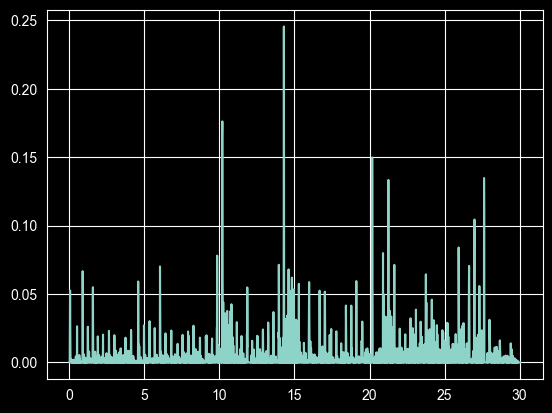

In [9]:
import matplotlib.pyplot as plt

(fs, x) = read(os.path.abspath(audio_files[99]))  # load sample from dataset
n = novelty(x, HOP_LENGTH, FRAME_LENGTH)

# calculate time axis for plot
frames=range(len(n))
t = librosa.frames_to_time(frames, sr=fs, hop_length=HOP_LENGTH)

plt.plot(t, n)

Let's also listen to the audio to see if the novelty functon seems to match.

In [10]:
from IPython.display import Audio

Audio(x, rate=fs)

Finally, we can generate this novelty function for all audios in the dataset.

In [11]:
# Make directory for novelty functions
novelty_dir = os.path.join(root, 'novelty')
os.makedirs(novelty_dir, exist_ok=True)

In [12]:
# Save novelty functions to novelty dir
done = 0
for file in audio_files:
    basename = os.path.basename(file)
    (fs, x) = read(file)
    n = novelty(x, HOP_LENGTH, FRAME_LENGTH)

    filename = basename.replace(".wav", ".npy")
    with open(os.path.join(novelty_dir, filename), 'wb') as f:
        np.save(f, n)

    done += 1
    print(f'[{done}/{len(audio_files)}] Completed file "{basename}" - novelty saved as "{filename}"', flush=True)

[698/698] Completed file "Albums-Latin_Jam3-07.wav" - novelty saved as "Albums-Latin_Jam3-07.npy"


# Onset Detection
Now that we have calculated our novelty function, the peaks should represent our onsets, or beats. However, in order to extract these beats from our novelty function, we need to set a threshold which peaks must surpass in order ot be considered. We can start by looking at a graph for one of the audio files, and where the beats are in the ground truth dataset, and try and pick a threshold from there.

In [13]:
def get_novelty(file):
    """Return the saved novelty array for a given audio file"""

    basename = os.path.basename(file)
    filename = basename.replace('.wav', '.npy')
    path = os.path.join(novelty_dir, filename)

    return np.load(path)

In [14]:
def get_ground_truth_beats(file):
    """Extract ground truth beat times for a given audio file"""

    # Get beat CSV path
    basename = os.path.basename(file)
    filename = basename.replace('.wav', '_beats.csv')
    path = os.path.join(beat_out, filename)

    onsets = []

    # Add each beat to an onset list
    with open(path) as f:
        reader = csv.DictReader(f)
        for row in reader:
            onsets.append(float(row['beat_time']))

    return np.array(onsets)  # return as numpy array

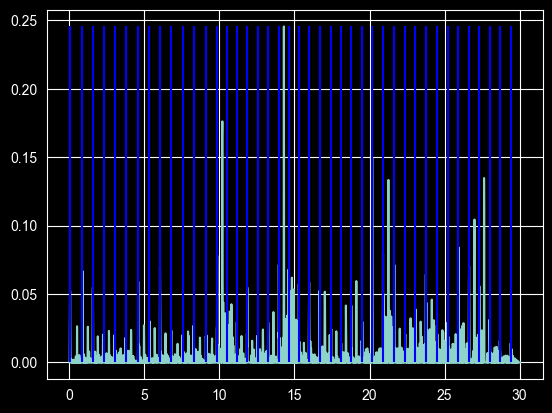

In [15]:
n = get_novelty(audio_files[99])
actual_beats = get_ground_truth_beats(audio_files[99])

plt.plot(t, n)
plt.vlines(actual_beats, 0, np.max(n), colors='b')

We can immediately see that we're gonna run into some problems here; notably some of our novelty function's highest peaks don't even fall on ground truth beats, and a lot of the ground truth peaks fall on very small peaks in the novelty function. We will revisit this later when we make our improved model. For now lets chug along and try and get some metrics on how well this baseline model performs. Let's go with a threshold of 0.05.

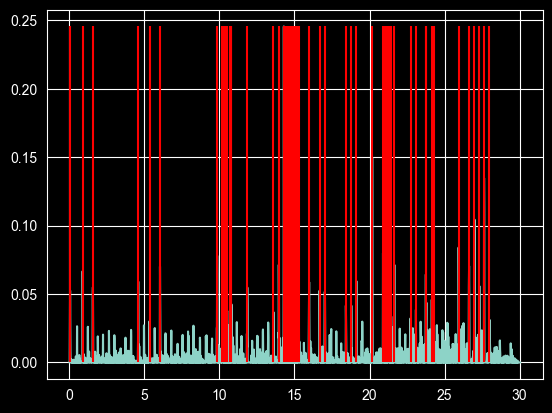

In [16]:
from scipy import signal

peaks, _ = signal.find_peaks(n, height=0.03)
peak_times = t[peaks]

plt.plot(t, n)
plt.vlines(peak_times, 0, np.max(n), colors='r')

Wow, that looks quite different. But it's alright&mdash; we will revisit this when we make an improved model. For now let's go with this threshold and move on to evaluation of the model, starting with this file specifically.

# Metrics and Evaluation
These evaluation metrics for onset detection come from the Music Information Retrieval Evaluation eXchange, or MIREX. Firstly, we will set a threshold of &pm;50ms for the timing of onsets. Correctly detected offsets will count as true positives, missed onsets will count as false negatives, and onsets detected not within 50ms of a ground truth onset will count as false positives. From this we can calculate both precision and recall as:
$$P=\frac{TP}{TP+FP}$$
$$R=\frac{TP}{TP+FN}$$
and an F1 score as:
$$F1=2\frac{P+R}{P\cdot R}$$
Let's write a function to calculate these metrics based on the model's detected onsets and the ground truth onsets

In [17]:
def metrics(beats, ground_truth):
    """Evaluate the onset detection model with three different metrics, given the detected onsets, and ground truth onsets"""

    # Count TPs, FPs, and FNs
    tp = fp = fn = j = 0

    # Iterate over detected beats
    for i in range(len(beats)):
        # All ground truth beats before the start of the tolerance range are false negatives
        while j < len(ground_truth) and ground_truth[j] < beats[i] - 0.05:
            j += 1
            fn += 1

        # Only a true positive if the current ground truth value is within the threshold,
        if j < len(ground_truth) and ground_truth[j] <= beats[i] + 0.05:
            j += 1
            tp += 1
        # Otherwise there were no ground truth beats within the threshold, and this onset is a false positive
        else:
            fp += 1

        i += 1

    # All remaining ground truth beats were not detected, and are false negatives
    while j < len(ground_truth):
        fn += 1
        j += 1

    precision = tp / max(tp + fp, 1)  # no division by 0
    recall = tp / max(tp + fn, 1)  # no division by 0

    f1 = 2 * (precision * recall) / max(precision + recall, 1e-6)  # no division by 0

    return precision, recall, f1


Testing this function on our file, we have:

In [18]:
precision, recall, f1 = metrics(peak_times, actual_beats)

print(f'Precision: {precision:.0%}\nRecall: {recall:.0%}\nF1 Score: {f1:.4f}')

Precision: 38%
Recall: 57%
F1 Score: 0.4528


# Baseline Approach
Not great, but it will only get better from here. This model is still a bit naive, since we somewhat arbitrarily picked our threshold value. Instead, lets split our data into training and testing data, and pick a threshold that results in the best (average) F1 score(s) among the training data.

In [19]:
def get_sample_rate(file):
    """Get the sample rate for a given audio file from the metadata table"""

    name = os.path.basename(file)
    meta_file = os.path.join(root, "metadata.csv")
    with open(meta_file, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if row['file'] == name:
                return float(row['sample rate'])

    return None


In [20]:
from sklearn.model_selection import train_test_split

data = []
labels = []

# Consolidate novelty functions and ground truth beats into lists
for file in audio_files:
    n = get_novelty(file)
    fs = get_sample_rate(file)
    b = get_ground_truth_beats(file)

    data.append((fs, n))
    labels.append(b)

# Split testing and training data
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=0.2, random_state=42)

Rather than brute forcing all possible tolerance values, we can more efficiently get to an ideal value using a simple gradient ascent algorithm. Essentially we will see how a small change in the tolerance threshold affects the F1 score, and use that information to move the tolerance towards an ideal value.

In [21]:
# GRADIENT ASCENT HYPERPARAMETERS
START_TOLERANCE = 0.05
TOLERANCE_DELTA = 0.0002
LEARNING_RATE = 0.0004
EPOCHS = 100

In [22]:
def evaluate_tolerance(tolerance):
    """Calculate the average f1 score across the training data for a single tolerance value"""

    total_f1 = 0

    for i in range(len(train_data)):
        fs, n = train_data[i]
        b = train_labels[i]

        frames=range(len(n))
        t = librosa.frames_to_time(frames, sr=fs, hop_length=HOP_LENGTH)

        peaks, _ = signal.find_peaks(n, height=tolerance)
        p = t[peaks]

        _, _, f1 = metrics(p, b)

        total_f1 += f1

    return total_f1 / len(train_data)

In [25]:
# Keep track of values across each epoch for plotting/finding the best tolerance in the end
epochs = []
tols = []
f1s = []

tol = START_TOLERANCE
for i in range(EPOCHS):
    print(f'Epoch {i+1}:', flush=True)
    print(f'\tEvaluating tolerance={tol:.5f}:', flush=True)

    # Calculate the tolerance and evaluate the gradient at this location
    f1 = evaluate_tolerance(tol)
    gradient = (evaluate_tolerance(tol + TOLERANCE_DELTA) - f1) / TOLERANCE_DELTA

    print(f'\tF1 Score: {f1:.4f}', flush=True)
    print(flush=True)

    epochs.append(i + 1)
    tols.append(tol)
    f1s.append(f1)

    # Gradient ascent step
    tol += LEARNING_RATE * gradient

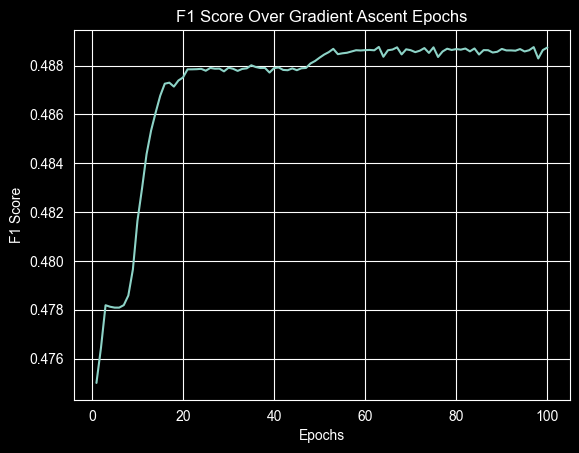

In [26]:
plt.plot(epochs, f1s)
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score Over Gradient Ascent Epochs')

In [27]:
tolerance = tols[np.argmax(f1s)]
print(f'Best Tolerance: {tolerance:.5f}')

Best Tolerance: 0.03729


Now that we have found an "ideal" tolerance threshold, we can evaluate our model on the training data:

In [28]:
avg_p = avg_r = avg_f1 = 0

# Calculate average percision, recall, and F1 score across TESTING data
for i in range(len(test_data)):
    fs, n = test_data[i]
    b = test_labels[i]

    frames=range(len(n))
    t = librosa.frames_to_time(frames, sr=fs, hop_length=HOP_LENGTH)

    peaks, _ = signal.find_peaks(n, height=tolerance)
    pt = t[peaks]

    p, r, f1 = metrics(pt, b)

    avg_p += p
    avg_r += r
    avg_f1 += f1

print(f'Average Precision: {avg_p / len(test_data):.2%}')
print(f'Average Recall: {avg_r / len(test_data):.2%}')
print(f'Average F1 Score: {avg_f1 / len(test_data):.4f}')

Average Precision: 42.51%
Average Recall: 60.45%
Average F1 Score: 0.4672


By optimizing our tolerance on the training data we reach a final testing F1 score of 0.4672 using a tolerance of 0.03729. However, these metrics still leave much to be desired, so let's see how we can make this better.

# Improved System
Now that we have a baseline system, we can start to make improvements to this model. Let's try and improve our model by using some different features for novelty. More detailed explanations of each can be found below.

## Feature Extraction

The first feature we will use is spectral flux, which will help us recognize spectral changes in the audio, rather than just overall amplitude changes.

In [29]:
def spectral_flux(x, hop_length, frame_length):
    """Calculate the spectral flux of an audio signal"""

    # Convert multi-channel audio to mono
    if len(x.shape) > 1:
        x = x.sum(axis=0)

    # Normalize audio signal
    x_norm = x / max(abs(x))

    # Calculate spectral flux
    stft = librosa.stft(x_norm, hop_length=hop_length, win_length=frame_length)
    diff = np.diff(np.abs(stft), axis=1)
    flux = np.sum(diff**2, axis=0)
    flux = np.concatenate(([0], flux))

    return flux / np.max(flux)  # normalize

The zero crossing rate will give us a sense of the instantaneous pitch of the signal, so we will include it as well. However, for novelty purposes, we really care about the change in instantaneous pitch, so lets use the first derivative. Let's also square it to make decreases in instantaneous frequency still appear positive.

In [30]:
def zero_crossing_rate(x, hop_length, frame_length):
    """Calculate the zero crossing rate of an audio signal"""

    # Convert multi-channel audio to mono
    if len(x.shape) > 1:
        x = x.sum(axis=0)

    # Normalize audio signal
    x_norm = x / max(abs(x))

    # Calculate zero crossing rate
    rate = librosa.feature.zero_crossing_rate(x_norm, hop_length=hop_length, frame_length=frame_length)
    diff_rate = np.diff(rate[0]) ** 2
    diff_rate = np.concatenate(([0], diff_rate))

    return diff_rate/np.max(diff_rate)  # normalize

Finally, the last feature we will include will be the Mel-Frequency Cepstral Coefficients. These will give more detailed data on the signal's timbre by essentially describing the power spectrum across different perceptual frequency bands. Since the MFCCs are effectively a power spectrum, we will do the same thing to them that we did to our RMSE- take the derivative and trim any negative values.

In [31]:
def mfcc(x, hop_length, frame_length):
    """Calculate the MFCCs of an audio signal"""

    # Convert multi-channel audio to mono
    if len(x.shape) > 1:
        x = x.sum(axis=0)

    # Normalize audio signal
    x_norm = x / max(abs(x))

    # Calculate mfcc's
    mfccs = librosa.feature.mfcc(y=x_norm, sr=fs, hop_length=hop_length, win_length=frame_length)
    diff_mfcc = np.diff(mfccs, axis=1)
    diff_mfcc[diff_mfcc < 0] = 0
    diff_mfcc = np.concatenate((np.zeros((diff_mfcc.shape[0], 1)), diff_mfcc), axis=1)

    return diff_mfcc.T/np.max(diff_mfcc, axis=1)  # normalize

Let's calculate and store these features for all of our audio files now, to avoid having to recalculate them later.

In [32]:
# Make directories for new features
sf_dir = os.path.join(root, 'spectral_flux')
zcr_dir = os.path.join(root, 'zero_crossing_rate')
mfcc_dir = os.path.join(root, 'mfcc_flux')

os.makedirs(sf_dir, exist_ok=True)
os.makedirs(zcr_dir, exist_ok=True)
os.makedirs(mfcc_dir, exist_ok=True)

In [32]:
# Store other features in their respective directories
done = 0
for file in audio_files:
    basename = os.path.basename(file)
    (fs, x) = read(file)
    flux = spectral_flux(x, HOP_LENGTH, FRAME_LENGTH)
    zcr = zero_crossing_rate(x, HOP_LENGTH, FRAME_LENGTH)
    mfccs = mfcc(x, HOP_LENGTH, FRAME_LENGTH)

    filename = basename.replace(".wav", ".npy")

    with open(os.path.join(sf_dir, filename), 'wb') as f:
        np.save(f, flux)
    with open(os.path.join(zcr_dir, filename), 'wb') as f:
        np.save(f, zcr)
    with open(os.path.join(mfcc_dir, filename), 'wb') as f:
        np.save(f, mfccs)

    done += 1
    print(f'[{done}/{len(audio_files)}] Completed file "{basename}" - features saved as "{filename}"', flush=True)

[698/698] Completed file "Albums-Latin_Jam3-07.wav" - features saved as "Albums-Latin_Jam3-07.npy"


In [33]:
def get_sf(file):
    """Return the saved spectral flux array for a given audio file"""

    basename = os.path.basename(file)
    filename = basename.replace('.wav', '.npy')
    path = os.path.join(sf_dir, filename)

    return np.load(path)

In [34]:
def get_zcr(file):
    """Return the saved zero crossing rate array for a given audio file"""

    basename = os.path.basename(file)
    filename = basename.replace('.wav', '.npy')
    path = os.path.join(zcr_dir, filename)

    return np.load(path)

In [35]:
def get_mfcc(file):
    """Return the saved MFCC array for a given audio file"""

    basename = os.path.basename(file)
    filename = basename.replace('.wav', '.npy')
    path = os.path.join(mfcc_dir, filename)

    return np.load(path)

Let's see is we can achieve any improvements by just using one of these features at a time and repeating the steps we took in the baseline approach.

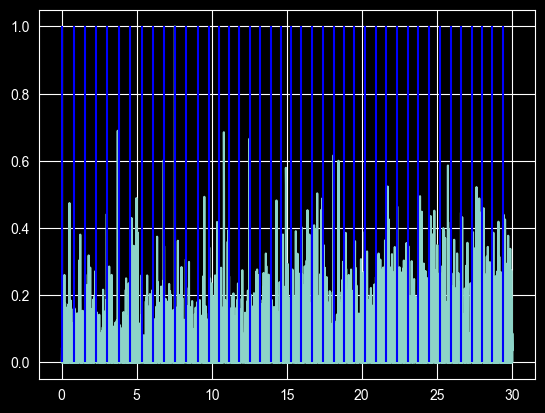

In [36]:
n = get_mfcc(audio_files[99])[:, 19]
fs = get_sample_rate(audio_files[99])
actual_beats = get_ground_truth_beats(audio_files[99])

# calculate time axis for plot
frames=range(len(n))
t = librosa.frames_to_time(frames, sr=fs, hop_length=HOP_LENGTH)

plt.plot(t, n)
plt.vlines(actual_beats, 0, 1, colors='b')

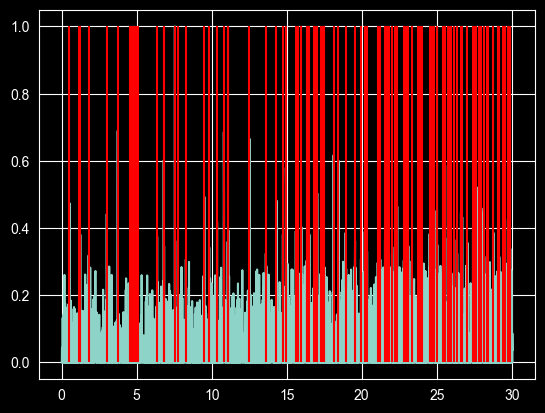

In [37]:
peaks, _ = signal.find_peaks(n, height=0.3)
peak_times = t[peaks]

plt.plot(t, n)
plt.vlines(peak_times, 0, 1, colors='r')

In [38]:
precision, recall, f1 = metrics(peak_times, actual_beats)

print(f'Precision: {precision:.0%}\nRecall: {recall:.0%}\nF1 Score: {f1:.4f}')

Precision: 20%
Recall: 48%
F1 Score: 0.2778


In [39]:
data = []
labels = []

# Consolidate novelty functions and ground truth beats into lists
for file in audio_files:
    n = get_mfcc(file)[:, 19]
    fs = get_sample_rate(file)
    b = get_ground_truth_beats(file)

    data.append((fs, n))
    labels.append(b)

# Split testing and training data
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=0.2, random_state=42)

In [40]:
# GRADIENT ASCENT HYPERPARAMETERS
START_TOLERANCE = 0.3
TOLERANCE_DELTA = 0.005
LEARNING_RATE = 0.008
EPOCHS = 100

In [41]:
# Keep track of values across each epoch for plotting/finding the best tolerance in the end
epochs = []
tols = []
f1s = []

tol = START_TOLERANCE
for i in range(EPOCHS):
    print(f'Epoch {i + 1}:', flush=True)
    print(f'\tEvaluating tolerance={tol:.5f}:', flush=True)

    # Calculate the tolerance and evaluate the gradient at this location
    f1 = evaluate_tolerance(tol)
    gradient = (evaluate_tolerance(tol + TOLERANCE_DELTA) - f1) / TOLERANCE_DELTA

    print(f'\tF1 Score: {f1:.4f}', flush=True)
    print(flush=True)

    epochs.append(i + 1)
    tols.append(tol)
    f1s.append(f1)

    # Gradient ascent step
    tol += LEARNING_RATE * gradient

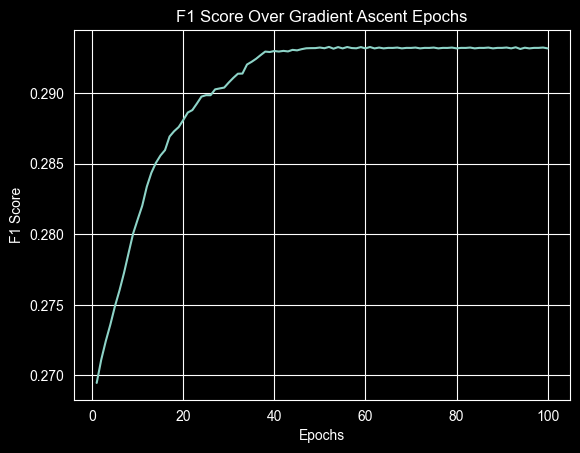

In [42]:
plt.plot(epochs, f1s)
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score Over Gradient Ascent Epochs')

In [43]:
tolerance = tols[np.argmax(f1s)]
print(f'Best Tolerance: {tolerance:.5f}')

Best Tolerance: 0.38006


In [44]:
avg_p = avg_r = avg_f1 = 0

# Calculate average percision, recall, and F1 score across TESTING data
for i in range(len(test_data)):
    fs, n = test_data[i]
    b = test_labels[i]

    frames = range(len(n))
    t = librosa.frames_to_time(frames, sr=fs, hop_length=HOP_LENGTH)

    peaks, _ = signal.find_peaks(n, height=tolerance)
    pt = t[peaks]

    p, r, f1 = metrics(pt, b)

    avg_p += p
    avg_r += r
    avg_f1 += f1

print(f'Average Precision: {avg_p / len(test_data):.2%}')
print(f'Average Recall: {avg_r / len(test_data):.2%}')
print(f'Average F1 Score: {avg_f1 / len(test_data):.4f}')

Average Precision: 20.24%
Average Recall: 56.66%
Average F1 Score: 0.2870


I will fill in the results for each feature in the below table (including RMSE, which was used for our original novelty function), showing the final Test F1 score, as well as the tolerance used to obtain that score.
| Feature | Tolerance | F1 Score |
| --- | --- | --- |
| RMSE | 0.0373 | 0.4672
| Spectral Flux | 0.2080 | 0.3796 |
| ZCR | 0.0546 | 0.2782 |
| MFCC 0 | 0.1920 | 0.4813 |
| MFCC 1 | 0.2029 | 0.3110 |
| MFCC 2 | 0.3465 | 0.3334 |
| MFCC 3 | 0.3451 | 0.3511 |
| MFCC 4 | 0.3807 | 0.3177 |
| MFCC 5 | 0.3742 | 0.3245 |
| MFCC 6 | 0.3937 | 0.3028 |
| MFCC 7 | 0.3873 | 0.3285 |
| MFCC 8 | 0.3862 | 0.2916 |
| MFCC 9 | 0.4018 | 0.3162 |
| MFCC 10 | 0.3855 | 0.2982 |
| MFCC 11 | 0.4136 | 0.3046 |
| MFCC 12 | 0.3658 | 0.2947 |
| MFCC 13 | 0.3825 | 0.2957 |
| MFCC 14 | 0.3800 | 0.2875 |
| MFCC 15 | 0.3946 | 0.2937 |
| MFCC 16 | 0.3729 | 0.2824 |
| MFCC 17 | 0.3829 | 0.2867 |
| MFCC 18 | 0.3766 | 0.2722 |
| MFCC 19 | 0.3801 | 0.2870 |

Only one of these features provides any improvement on its own (MFCC 0), but, the real improvement comes in when we begin to combine these features to make a new novelty function. In order to optimize our new novelty function, we will take a weighted sum of our features, and instead of simply optimizing our tolerance value, we will optimize these weights first by testing many different possible combinations, and optimizing further from there. Let's create a model combining the three features that provided the best results individually- MFCC 0, RMSE, and Spectral Flux. Let's see how the model performs if we simply add the three functions together with no weights.

In [71]:
data = []
labels = []

# Consolidate features functions and ground truth beats into lists
for file in audio_files:
    fs = get_sample_rate(file)

    n = get_novelty(file)
    sf = get_sf(file)
    mfcc = get_mfcc(file)

    feats = np.stack([n, sf, mfcc[:, 0]], axis=1)
    b = get_ground_truth_beats(file)

    data.append((fs, np.sum(feats, axis=1)))
    labels.append(b)

# Split testing and training data
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=0.2, random_state=42)

In [69]:
avg_p = avg_r = avg_f1 = 0

# Calculate average percision, recall, and F1 score across TESTING data
for i in range(len(test_data)):
    fs, n = test_data[i]

    b = test_labels[i]

    frames = range(len(n))
    t = librosa.frames_to_time(frames, sr=fs, hop_length=HOP_LENGTH)

    peaks, _ = signal.find_peaks(n, height=0.5)
    pt = t[peaks]

    p, r, f1 = metrics(pt, b)

    avg_p += p
    avg_r += r
    avg_f1 += f1

print(f'Average Precision: {avg_p / len(test_data):.2%}')
print(f'Average Recall: {avg_r / len(test_data):.2%}')
print(f'Average F1 Score: {avg_f1 / len(test_data):.4f}')

Average Precision: 51.41%
Average Recall: 47.88%
Average F1 Score: 0.4598


Not quite an improvement yet. But, we haven't utilized our training data at all to optimize our weights. Let's start by finding ideal starting weights, so we can hopefully optimize towards a global maximum with our gradient ascent. We will simply iterate through many different options for weights, and pick the best one.

In [44]:
data = []
labels = []

# Consolidate novelty functions and ground truth beats into lists
for file in audio_files:
    fs = get_sample_rate(file)

    n = get_novelty(file)
    sf = get_sf(file)
    mfcc = get_mfcc(file)

    feats = np.stack([n, sf, mfcc[:, 0]], axis=1)
    b = get_ground_truth_beats(file)

    data.append((fs, feats))
    labels.append(b)

# Split testing and training data
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=0.2, random_state=42)

In [45]:
def evaluate(fs, features, weights):
    # Weighted sum of features
    n = np.dot(features, weights)
    ept, _ = signal.find_peaks(n, height=0.5)

    # Get peak times
    eframes = range(len(n))
    etf = librosa.frames_to_time(eframes, sr=fs, hop_length=HOP_LENGTH)

    epks = etf[ept]
    return epks

In [46]:
def evaluate_all(weights):
    # Calculate average f1 score over all training data
    tot_f1 = 0

    for i in range(len(train_data)):
        b = evaluate(*train_data[i], weights)
        _, _, f1 = metrics(b, train_labels[i])

        tot_f1 += f1

    return tot_f1 / len(train_data)

In [49]:
# Find best starting weights by checking all possible combinations
max_weights = np.zeros(3)
max_f1 = 0

count = 0
for i in range(0, 15, 1):
    for j in range(0, 15, 1):
        print(f'{count/(15**2):.2%}', flush=True)  # this seems to print weirdly but whatever
        count += 1

        for k in range(0, 15, 1):
            # Check this weight combination
            weights = np.array([i, j, k]) / 10
            f1 = evaluate_all(weights)

            if f1 > max_f1:
                max_f1 = f1
                max_weights = weights

KeyboardInterrupt: 

In [ ]:
print(f'Best Weights: {max_weights}')
print(f'Best F1 Score: {max_f1:.4f}')

Now that we have a good place to start, we will continue optimization with a similar gradient ascent algorithm to what we used for tolerance optimization. This time though, we just have to expand the algorithm to multiple weights. We will test the effect each weight has on the F1 Score individially, and those individual gradients will compose the vector that we use to adjust the weights at the end of each epoch.

In [ ]:
def epoch(w, delta, lr):
    # Evaluate original F1 Score
    base_f1 = evaluate_all(w)
    grad = np.zeros_like(w)

    # Create gradient vector by testing each weight
    for i in range(len(grad)):
        new_weights = np.copy(w)
        new_weights[i] += delta

        new_f1 = evaluate_all(new_weights)
        grad[i] = (new_f1 - base_f1) / delta

    # Return adjusted weights and epoch F1 score
    return w + lr * grad, base_f1

In [59]:
# GRADIENT ASCENT HYPERPARAMETERS
DELTA = 0.01
LEARNING_RATE = 0.07
EPOCHS = 500

In [48]:
weights = max_weights.copy()

epochs = []
f1s = []
all_weights = []

for i in range(EPOCHS):
    weights, f1 = epoch(weights, DELTA, LEARNING_RATE)

    epochs.append(i + 1)
    f1s.append(f1)
    all_weights.append(weights)

    print(f'Epoch {i + 1} - F1 Score: {f1}', flush=True)

NameError: name 'epoch' is not defined

In [ ]:
plt.plot(epochs, f1s)
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score Over Gradient Ascent Epochs')

In [63]:
weights = all_weights[np.argmax(f1s)]
print(f'Best Weights: {weights}')

Best Weights: [1.59518808 0.89276187 1.62964896]


In [75]:
avg_p = avg_r = avg_f1 = 0

# Calculate average percision, recall, and F1 score across TESTING data
for i in range(len(test_data)):
    fs, feats = test_data[i]
    n = np.dot(feats, weights)

    b = test_labels[i]

    frames = range(len(n))
    t = librosa.frames_to_time(frames, sr=fs, hop_length=HOP_LENGTH)

    peaks, _ = signal.find_peaks(n, height=0.5)
    pt = t[peaks]

    p, r, f1 = metrics(pt, b)

    avg_p += p
    avg_r += r
    avg_f1 += f1

print(f'Average Precision: {avg_p / len(test_data):.2%}')
print(f'Average Recall: {avg_r / len(test_data):.2%}')
print(f'Average F1 Score: {avg_f1 / len(test_data):.4f}')

Average Precision: 47.06%
Average Recall: 63.21%
Average F1 Score: 0.5043


This results in a decent improvement to our F1 score (0.4671 to 0.5043), but taking a closer look at our metrics, our recall is a bit higher than in our baseline model at 63.21% compared to the original 60.45%, and there had been a significant increase in the model's precision, finishing at 47.06%, an almost 5% increase from the original 42.51%. This means we have acieved an improvement in all three metrics! Please see eval.ipynb for a final evaluation of the models.

# Tempo Estimation

For the extension task, we will extend our onset detection algorithm to estimate the tempo of each track. A simple way to do this is to take our improved novelty function, and apply autocorrelation. Let's look at this process for a single audio file first.

In [51]:
weights = np.array([1.59518808, 0.89276187, 1.62964896])

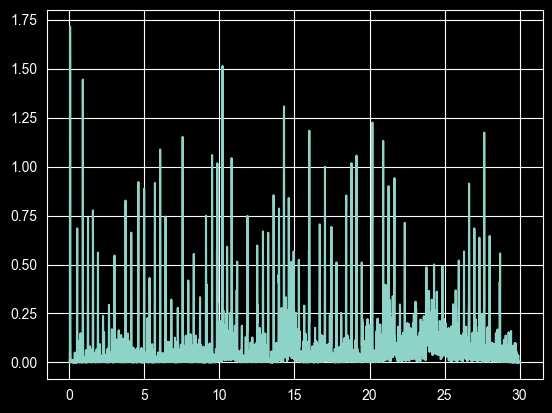

In [112]:
# Get features
fs = get_sample_rate(audio_files[99])

n = get_novelty(audio_files[99])
sf = get_sf(audio_files[99])
mfcc = get_mfcc(audio_files[99])

# Calculate new novelty function
feats = np.stack([n, sf, mfcc[:, 0]], axis=1)
improved = np.dot(feats, weights)

# Calculate time scale
frames = range(len(improved))
t = librosa.frames_to_time(frames, sr=fs, hop_length=HOP_LENGTH)

# Plot improved novelty function
plt.plot(t, improved)

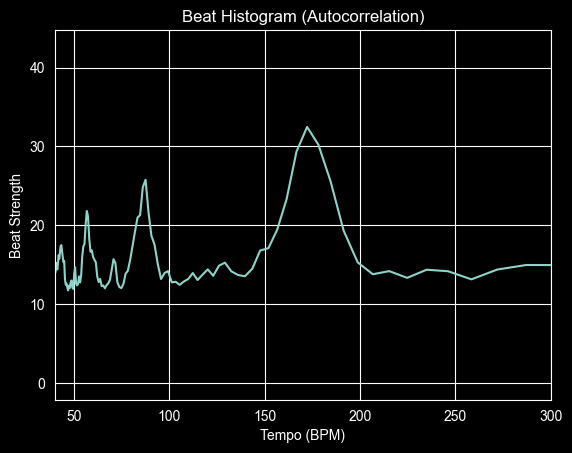

In [113]:
# Use autocorrelation to find possible tempos and strengths
ac = librosa.autocorrelate(improved)
lags = np.arange(len(ac))
lag_times = lags * HOP_LENGTH / fs
bpms = 60 / lag_times[1:]   # avoid divide by zero
strength = ac[1:]

# Plot beat histogram
plt.plot(bpms, strength)
plt.xlim(40, 300)
plt.xlabel("Tempo (BPM)")
plt.ylabel("Beat Strength")
plt.title("Beat Histogram (Autocorrelation)")

In [114]:
# Find peaks in beat histogram
pks, feats = signal.find_peaks(strength, height=10)
confidence = np.stack([bpms[pks], feats['peak_heights']], axis=1)
confidence = confidence[np.logical_and(confidence[:, 0] > 40, confidence[:, 0] < 300)]  # only pick tempos between 40 and 300
confidence[np.argmax(confidence[:, 1])][0]

172.265625

In [115]:
def get_ground_truth_tempo(file):
    """Retrieve the stored ground truth tempo"""

    # Get tempo CSV path
    basename = os.path.basename(file)
    filename = basename.replace('.wav', '_tempo.csv')
    path = os.path.join(tempo_out, filename)

    # Add each beat to an onset list
    with open(path) as f:
        reader = csv.DictReader(f)
        for row in reader:
            return float(row['tempo_bpm'])

    return 0

In [116]:
get_ground_truth_tempo(audio_files[99])

84.0

So we got a value that was approximately double the actual tempo for this file specifically. We will revisit this issue later. For now, let's see how many of the testing files we can correctly calculate tempo for. We will count anything within 8% of the actual tempo as a correct estimation (this is a common tolerance for tempo estimation, and is used by MIREX's tempo evaluation standard).

In [117]:
def estimate_tempo(fs, novelty):
    """Estimate the tempo of a track given the novelty functio (and sample rate)"""

    ac = librosa.autocorrelate(novelty)
    lags = np.arange(len(ac))
    lag_times = lags * HOP_LENGTH / fs
    bpms = 60 / lag_times[1:]   # avoid divide by zero
    strength = ac[1:]

    pks, feats = signal.find_peaks(strength, height=0)
    confidence = np.stack([bpms[pks], feats['peak_heights']], axis=1)

    confidence = confidence[np.logical_and(confidence[:, 0] > 40, confidence[:, 0] < 300)]
    return confidence[np.argmax(confidence[:, 1])][0]

In [58]:
data = []
labels = []

# Consolidate calculate new novelty functions save them as well as ground truth tempos into lists
for file in audio_files:
    fs = get_sample_rate(file)

    n = get_novelty(file)
    sf = get_sf(file)
    mfcc = get_mfcc(file)

    feats = np.stack([n, sf, mfcc[:, 0]], axis=1)
    improved = np.dot(feats, weights)
    tempo = get_ground_truth_tempo(file)

    data.append((fs, improved))
    labels.append(tempo)

# Split testing and training data
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=0.2, random_state=42)

In [60]:
count = 0

for i in range(len(test_data)):
    est_tempo = estimate_tempo(*test_data[i])
    actual_tempo = test_labels[i]

    if 0.92 <= est_tempo / actual_tempo <= 1.08:  # 8% tolerance threshold
        count += 1

print(f'Tempo correct for {count}/{len(test_data)} tracks ({count / len(test_data):.2%})')

Tempo correct for 51/140 tracks (36.43%)


Not great accuracy to start. Let's see if we can get a better idea of what errors exactly the model is making. Switching over to the training dataset, let's plot the estimated vs acutal tempos.

In [118]:
est_tempos = []
actual_tempos = []

for i in range(len(train_data)):
    est_tempo = estimate_tempo(*train_data[i])
    actual_tempo = train_labels[i]

    est_tempos.append(est_tempo)
    actual_tempos.append(actual_tempo)

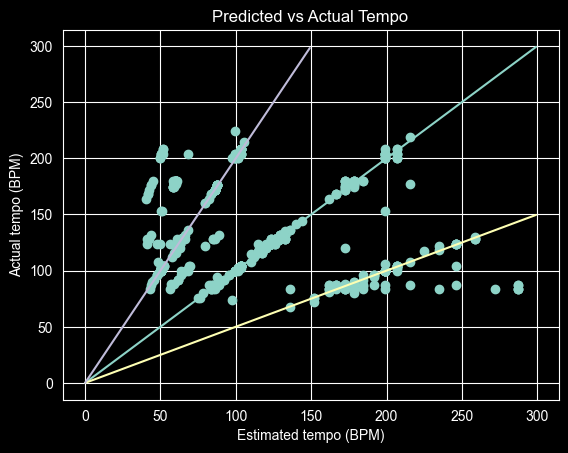

In [120]:
plt.scatter(est_tempos, actual_tempos)

x1 = np.arange(300)
x2 = np.arange(150)

y1 = 1 / 2 * x1
y2 = 2 * x2

plt.plot(x1, x1)
plt.plot(x1, y1)
plt.plot(x2, y2)

plt.ylabel("Actual tempo (BPM)")
plt.xlabel("Estimated tempo (BPM)")
plt.title("Predicted vs Actual Tempo")

The three lines on the plot represent the correctly estimated tempos, as well as doubled and halved tempos. We can see that there are quite a few datapoints falling on the doubled and halved lines. In most of these cases, the estimate is somewhere on the low or high end of our reasonable tempo range (40 to 300). Let's take a better look at the actual distribution of tempos within our data.

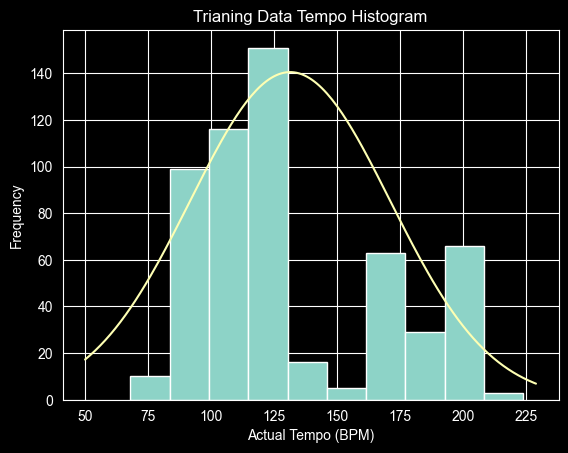

In [121]:
from scipy.stats import norm

mean = np.mean(actual_tempos)
std = np.std(actual_tempos)

x = np.arange(50, 230)
y = norm.pdf(x, mean, std)

plt.hist(actual_tempos)
plt.plot(x, y * 14000)

plt.title("Trianing Data Tempo Histogram")
plt.xlabel("Actual Tempo (BPM)")
plt.ylabel("Frequency")

The overlaid function is a normal PDF. The distribution looks almost normal, at least on the left side, theres just a bit of a gap between 130 and 160 BPM. Anyways, we can use this normal PDF along with the calculated training data mean and standard deviation to adjust our confidence values to more highly weight tempos in the most common part of the reasonable range. This should help push the correct values higher than the halved or doubled values (in some cases).

In [72]:
def estimate_tempo(fs, novelty):
    ac = librosa.autocorrelate(novelty)
    lags = np.arange(len(ac))
    lag_times = lags * HOP_LENGTH / fs
    bpms = 60 / lag_times[1:]   # avoid divide by zero
    strength = ac[1:]

    pks, feats = signal.find_peaks(strength, height=0)
    confidence = np.stack([bpms[pks], feats['peak_heights']], axis=1)

    confidence = confidence[np.logical_and(confidence[:, 0] > 40, confidence[:, 0] < 300)]
    pdf = norm.pdf(confidence[:, 0], mean, std)
    confidence[:, 1] *= pdf

    return confidence[np.argmax(confidence[:, 1])][0]

In [74]:
count = 0

est_tempos = []
actual_tempos = []

for i in range(len(test_data)):
    est_tempo = estimate_tempo(*test_data[i])
    actual_tempo = test_labels[i]

    est_tempos.append(est_tempo)
    actual_tempos.append(actual_tempo)

    if 0.92 <= est_tempo / actual_tempo <= 1.08:  # 8% tolerance threshold
        count += 1

print(f'Tempo correct for {count}/{len(test_data)} tracks ({count / len(test_data):.2%})')

Tempo correct for 64/140 tracks (45.71%)


This improved our accuracy a great deal! If we do the same actual vs estimated tempo scatter plot we can see just how much of the half and double errors we avoided.

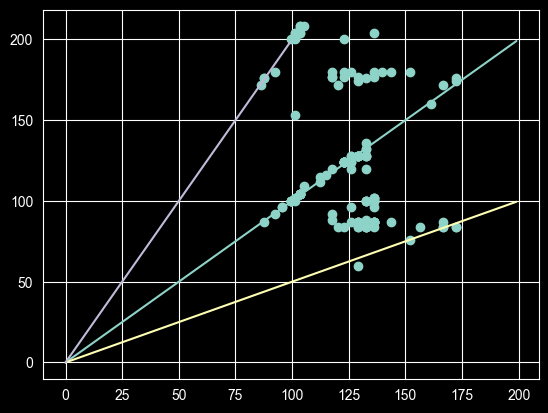

In [78]:
plt.scatter(est_tempos, actual_tempos)

x1 = np.arange(200)
x2 = np.arange(100)

y1 = 1 / 2 * x1
y2 = 2 * x2

plt.plot(x1, x1)
plt.plot(x1, y1)
plt.plot(x2, y2)

It seems like the biggest sources of error now are the clumps of points between the three lines. These likely arise from more complicated subdivisions, or just as a result of the imperfect novelty function itself.